# <center> Кластеризация изображений транспортных средств

## Постановка задачи

<center> <img src=https://i.ibb.co/t8DvkyB/smart-city-image-1.jpg align="right" width="300"/> </center>
<center> <img src=https://i.ibb.co/qYkWNVh/smart-city-image-3.jpg align="right" width="300"/> </center>


Один из ключевых проектов IntelliVision — Smart City/Transportation, система, обеспечивающая безопасность дорожного движения и более эффективную работу парковок. С помощью Smart City/Transportation можно контролировать сигналы светофоров и соблюдение ограничений скорости, определять виды транспортных средств, распознавать номерные знаки, считать автомобили и людей.

В основе всех перечисленных возможностей проекта лежит CV (Computer Vision, компьютерное зрение). Чтобы их реализовать, компания использует модели, для обучения которых применяются огромные размеченные датасеты с изображениями транспортных средств. Однако система работает в режиме реального времени и с каждым днём данных становится всё больше. Алгоритм нуждается в постоянной модернизации и должен учитывать множество факторов.

Для модификации и повышения эффективности системы Smart City/Transportation команде необходимо автоматизировать определение дополнительных параметров авто на изображении:

* тип автомобиля (кузова),
* ракурс снимка (вид сзади/спереди),
* цвет автомобиля,
* другие характеристики.

Также необходимо автоматизировать поиск выбросов в данных (засветы и блики на изображениях, изображения, на которых отсутствуют автомобили и т. д.).

К сожалению, у компании нет комплексной модели, которая могла бы одновременно находить на изображении автомобиль и определять все нужные параметры. Её нужно построить, однако многокомпонентная разметка новых данных по всем этим параметрам — очень трудозатратное занятие, которое стоит больших денег.

При решении задачи разметки данных у команды возникла гипотеза, которая нуждается в исследовании.


**Гипотеза:** разметку исходных данных можно эффективно провести с помощью методов кластеризации. 


**В чём идея?**

*Давайте будем использовать небольшой набор моделей свёрточных нейронных сетей, обученных на различных датасетах и решающих различные задачи от классификации изображений по цвету до классификации типов транспортных средств, пропустим нашу базу изображений через каждую модель, но возьмём не выходной результат модели, а только промежуточное представление признаков (дескриптор), полученное на свёрточных слоях сети.*

*Выполним такую операцию для всех изображений из набора данных, на основе полученных дескрипторов кластеризуем изображения, проинтерпретируем полученные кластеры и попробуем найти в них необходимую информацию.*

Теперь, когда мы обсудили гипотезу, перейдём к постановке задачи.

<center> <img src=https://i.ibb.co/hLcBpZF/2023-03-27-12-11-17.png align="right" width="500"/> </center>

У нас будет набор из 416 314 изображений транспортных средств различных типов, цветов и снятых с разных ракурсов.

Команда IntelliVision уже обработала свой набор данных с помощью нескольких моделей глубокого обучения (свёрточных нейронных сетей) и получила четыре варианта вектора признаков (дескрипторов) для каждого изображения.

**Наша задача** — используя готовые дескрипторы, разбить изображения на кластеры и проинтерпретировать каждый из них. Для всех вариантов дескрипторов нужно применить несколько алгоритмов кластеризации и сравнить полученные результаты. Сравнивать можно на основе метрик, визуализаций плотностей кластеров и по тому, насколько хорошо интерпретируются кластеры.

Дополнительная подзадача — найти выбросы среди изображений. Это могут быть изображения плохого качества, изображения с бликами или изображения, на которых нет транспортных средств и т. д.

Бизнес-задача: исследовать возможность применения алгоритмов кластеризации для разметки новых данных и поиска выбросов.

Техническая задача для нас как для специалиста в Data Science: построить модель кластеризации изображений на основе дескрипторов, выделяемых с помощью различных архитектур нейронных сетей, проинтерпретировать полученные результаты и выбрать модель или комбинацию моделей, которая выделяет наиболее пригодные для интерпретации признаки.

**Наши основные цели:**
1. Для каждого типа дескрипторов необходимо:
    * выполнить предобработку дескрипторов;
    * произвести кластеризацию изображений на основе их дескрипторов, подобрав алгоритм и параметры кластеризации;
    * сделать визуализацию полученных кластеров в 2D- или 3D-пространстве;
    * проинтерпретировать полученные кластеры — в паре предложений сформулировать, какие изображения попали в каждый из кластеров.
2. Сравнить между собой полученные кластеризации для каждого типа дескрипторов (по метрикам, визуализации и результатам интерпретации).
3. Выполнить автоматизированный поиск выбросов среди изображений на основе дескрипторов.
4. Дополнительная задача: попробовать воспользоваться смесью дескрипторов, полученных различными моделями, и проинтерпретировать полученные результаты.

**Примечание.** При выборе алгоритма кластеризации будем ориентироваться на внутренние метрики, а именно на индекс Калински — Харабаса (`calinski_harabasz_score`) и индекс Дэвиса — Болдина (`davies_bouldin_score`), а также на интерпретируемость кластеров и визуализацию.

## Данные и их описание

Исходная папка с данными имеет следующую структуру:

```
IntelliVision_case
├─descriptors
    └─efficientnet-b7.pickle
    └─osnet.pickle
    └─vdc_color.pickle
    └─vdc_type.pickle
├─row_data
    └─veriwild.zip
├─images_paths.csv 
```

Давайте разберёмся в ней:

* В папке `descriptors` содержатся дескрипторы, полученные для каждого из изображений с помощью соответствующих нейронных сетей, в формате numpy-массивов, сохранённых в файлах pickle:
    * `efficientnet-b7.pickle` — дескрипторы, выделенные моделью классификации с архитектурой EfficientNet версии 7. Эта модель является свёрточной нейронной сетью, предобученной на на датасете ImageNet, в котором содержатся изображения более 1000 различных классов. Эта модель при обучении не видела датасета veriwiId. 

    * `osnet.pickle` — дескрипторы, выделенные моделью OSNet, обученной для детектирования людей, животных и машин. Модель не обучалась на исходном датасете veriwiId.

    * `vdc_color.pickle` — дескрипторы, выделенные моделью регрессии для определения цвета транспортных средств в формате RGB. Частично обучена на исходном датасете veriwild.
    
    * `vdc_type.pickle` — дескрипторы, выделенные моделью классификации транспортных средств по типу на десяти классах. Частично обучена на исходном датасете veriwild.

* В папке `row_data` содержится zip-архив с исходными изображениями автомобилей. Распакуйте его содержимое в папку row_data. Архив содержит десять папок с изображениями, пронумерованных от 1 до 10. Каждая папка содержит подпапки, обозначенные пятизначными цифрами, например 36191. 

В каждой из таких подпапок содержатся фотографии одного конкретного автомобиля с разных ракурсов, снятые с помощью дорожных видеокамер.

* В файле `images_paths.csv` представлен список из полных путей до изображений. Он пригодится вам при анализе изображений, попавших в определённый кластер.


## 1. Знакомство со структурой данных

Прочитаем numpy-массивы из предоставленных pickle-файлов.

Примечание Для удобства дальнейшей работы составим четыре DataFrame с путями до изображений и соответствующими им дескрипторами.

Посмотрим на размерности каждой из четырёх заданных матриц и сравните использованные модели глубокого обучения по размерностям выходных дескрипторов изображений.

In [25]:
# Базовый путь к датасету
BASE_PATH = '/kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case'

# Пути к дескрипторам
efficientnet_path = f'{BASE_PATH}/descriptors/efficientnet-b7.pickle'
osnet_path = f'{BASE_PATH}/descriptors/osnet.pickle'
vdc_color_path = f'{BASE_PATH}/descriptors/vdc_color.pickle'
vdc_type_path = f'{BASE_PATH}/descriptors/vdc_type.pickle'
# Путь к CSV с путями изображений
images_paths = f'{BASE_PATH}/images_paths.csv'

In [26]:
# Загружаем пути к изображениям
import pandas as pd
import pickle

paths_df = pd.read_csv(images_paths)

import os
# Функция для загрузки дескрипторов
def load_descriptors(file_path, name):
    print(f"\nЗагрузка {name}...")
    if os.path.exists(file_path):
        with open(file_path, 'rb') as f:
            descriptors = pickle.load(f)
        print(f"  Файл: {file_path}")
        print(f"  Форма массива: {descriptors.shape}")
        print(f"  Тип данных: {descriptors.dtype}")
        return descriptors
    else:
        print(f"  Файл НЕ НАЙДЕН: {file_path}")
        return None

# Загружаем все дескрипторы
X_ef = load_descriptors(efficientnet_path, "EfficientNet")
X_osnet = load_descriptors(osnet_path, "OSNet")
X_color = load_descriptors(vdc_color_path, "VDC Color")
X_type = load_descriptors(vdc_type_path, "VDC Type")


Загрузка EfficientNet...
  Файл: /kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case/descriptors/efficientnet-b7.pickle
  Форма массива: (416314, 2560)
  Тип данных: float32

Загрузка OSNet...
  Файл: /kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case/descriptors/osnet.pickle
  Форма массива: (416314, 512)
  Тип данных: float32

Загрузка VDC Color...
  Файл: /kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case/descriptors/vdc_color.pickle
  Форма массива: (416314, 128)
  Тип данных: float32

Загрузка VDC Type...
  Файл: /kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case/descriptors/vdc_type.pickle
  Форма массива: (416314, 512)
  Тип данных: float32


## 2. Преобразование, очистка и анализ данных

Признаки, найденные с помощью некоторых моделей, исчисляются тысячами, что довольно много, учитывая общее количество наблюдений.

Как вы понимаете, производить кластеризацию на таком большом количестве признаков, которые были сформированы исходными моделями глубокого обучения, довольно сложно и затратно по времени. К тому же, многие признаки, найденные моделями на изображениях, могут быть сильно скоррелированы между собой.

Будем понижать размерность исходных дескрипторов с помощью соответствующих методов. Можно уменьшить размерность входных данных до 100 или 200 признаков — этого будет достаточно, чтобы произвести кластеризацию. Попробуем подобрать необходимое количество компонент в новом пространстве признаков.

Для работы в общем масштабе признаков, воспользуемся стандартизацией и нормализацией.

In [ ]:
# Предобработка данных: Стандартизация и уменьшение размерности
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Создадим словарь с дескрипторами для удобной обработки
descriptors_dict = {
    'EfficientNet': X_ef,
    'OSNet': X_osnet,
    'VDC_Color': X_color,
    'VDC_Type': X_type
}

# Словарь для хранения обработанных данных
processed_descriptors = {}

# Обрабатываем каждый тип дескрипторов
for name, X in descriptors_dict.items():
    print(f"\nОбработка {name}...")
    print(f"  Исходная размерность: {X.shape}")
    
    # 1. Стандартизация
    print("  Шаг 1: Стандартизация (StandardScaler)")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Уменьшение размерности до 100 компонент (PCA)
    print("  Шаг 2: Уменьшение размерности PCA до 100 компонент")
    pca = PCA(n_components=100, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # Сохраняем обработанные данные
    processed_descriptors[name] = X_pca
    print(f"  Результат: {X_pca.shape}")
    print(f"  Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

print("\n" + "="*60)
print("ПРЕДОБРАБОТКА ЗАВЕРШЕНА")
print("="*60)


Обработка EfficientNet...
  Исходная размерность: (416314, 2560)
  Шаг 1: Стандартизация (StandardScaler)
  Шаг 2: Уменьшение размерности PCA до 100 компонент


### Анализ результатов PCA

Мы выполнили PCA для всех четырех типов дескрипторов, уменьшив размерность до 100 компонент. Полученные результаты показывают разную степень сжатия информации:

| Модель | Исходная размерность | Объясненная дисперсия (100 компонент) |
|--------|---------------------|--------------------------------------|
| EfficientNet | 2560 | 46.15% |
| OSNet | 512 | 84.06% |
| VDC_Color | 128 | 97.07% |
| VDC_Type | 512 | 97.66% |

**Что это значит:**
- Для EfficientNet 100 компонент недостаточно (только 46% информации)
- Для VDC_Color и VDC_Type можно взять меньше компонент (информация очень сжата)
- Для OSNet 100 компонент дают хороший результат (84%)

**Следующий шаг:** подберем оптимальное количество компонент для каждого типа дескрипторов (чтобы сохранить 95% дисперсии) и выполним финальную предобработку.

In [ ]:
# Подбор оптимального количества компонент PCA и финальная предобработка
import numpy as np

# Словарь для хранения оптимальных параметров
pca_params = {}
processed_descriptors = {}

for name, X in descriptors_dict.items():
    print(f"\nАнализ для {name} (исходная размерность: {X.shape[1]})...")
    
    # Стандартизация
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA для анализа
    pca = PCA(random_state=42)
    pca.fit(X_scaled)
    
    # Считаем кумулятивную объясненную дисперсию
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    
    # Находим количество компонент для 95% дисперсии
    n_components_95 = np.argmax(cumsum >= 0.95) + 1
    variance_95 = cumsum[n_components_95 - 1] * 100
    
    print(f"  Компонент для 95% дисперсии: {n_components_95}")
    print(f"  Фактическая дисперсия: {variance_95:.2f}%")
    
    # Сохраняем параметры
    pca_params[name] = n_components_95
    
    # Выполняем финальное PCA с оптимальным количеством компонент
    print(f"  Выполняем PCA до {n_components_95} компонент...")
    pca_final = PCA(n_components=n_components_95, random_state=42)
    X_pca = pca_final.fit_transform(X_scaled)
    
    processed_descriptors[name] = X_pca
    print(f"  Результат: {X_pca.shape}")
    print(f"  Объясненная дисперсия: {pca_final.explained_variance_ratio_.sum():.2%}")

print("\n" + "="*60)
print("ПРЕДОБРАБОТКА ЗАВЕРШЕНА")
print("="*60)
print("\nИтоговые размерности:")
for name, X in processed_descriptors.items():
    print(f"  {name}: {X.shape}")

### Анализ результатов подбора оптимальной размерности

Мы выполнили PCA для каждого типа дескрипторов, подобрав количество компонент, сохраняющее 95% исходной информации.

**Итоговые размерности после предобработки:**

| Модель | Исходная размерность | Оптимальная размерность (95%) | Сжатие |
|--------|---------------------|-------------------------------|--------|
| EfficientNet | 2560 | 1807 | в 1.4 раза |
| OSNet | 512 | 235 | в 2.2 раза |
| VDC_Color | 128 | 90 | в 1.4 раза |
| VDC_Type | 512 | 46 | в 11.1 раза |

**Полученные результаты:**

1. **EfficientNet**: 2560 → 1807 признаков (95% информации)
2. **OSNet**: 512 → 235 признаков (95% информации)  
3. **VDC_Color**: 128 → 90 признаков (95% информации)
4. **VDC_Type**: 512 → 46 признаков (95% информации)

Дополнительные методы уменьшения размерности не требуются, так как задача решена — данные подготовлены для кластеризации с сохранением основного объема информации.

## 3. Моделирование и оценка качества модели

### 3.1. Кластеризация изображений

После предобработки данных приступаем к кластеризации. Для каждого типа дескрипторов применим несколько алгоритмов кластеризации и подберем оптимальное количество кластеров.

**Используемые алгоритмы:**
- **K-Means** (через MiniBatchKMeans для больших данных)
- **EM-алгоритм** (Gaussian Mixture Model)
- **Агломеративная иерархическая кластеризация** (с ограничением по глубине)
- **DBSCAN** (для поиска кластеров произвольной формы)

**Метрики качества:**
- **индекс Калински-Харабаса** (чем выше, тем лучше)
- **индекс Дэвиса-Болдина** (чем ниже, тем лучше)

Для ускорения работы будем использовать подвыборку для некоторых алгоритмов (EM, агломеративная кластеризация), так как они требуют много памяти на полных данных.

In [6]:
# Кластеризация изображений

from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Словари для хранения результатов кластеризации
clustering_results = {}
cluster_labels = {}

# Количество кластеров для K-Means и EM (подбирается экспериментально)
# Для разных типов дескрипторов можно использовать разное количество кластеров
n_clusters = {
    'EfficientNet': 20,
    'OSNet': 15,
    'VDC_Color': 12,
    'VDC_Type': 10
}

# Применяем кластеризацию к каждому типу дескрипторов
for name, X in processed_descriptors.items():
    print(f"\n{'-'*60}")
    print(f"КЛАСТЕРИЗАЦИЯ ДЛЯ {name}")
    print(f"Размерность данных: {X.shape}")
    print(f"{'-'*60}")
    
    # Словарь для хранения результатов по данному типу дескрипторов
    results = {}
    labels_dict = {}
    
    # 1. MiniBatchKMeans (аналог K-Means для больших данных)
    print("\n1. MiniBatchKMeans...")
    k = n_clusters[name]
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=10000, random_state=42, n_init=3)
    labels_kmeans = kmeans.fit_predict(X)
    labels_dict['kmeans'] = labels_kmeans
    
    # Метрики
    ch_score = calinski_harabasz_score(X, labels_kmeans)
    db_score = davies_bouldin_score(X, labels_kmeans)
    results['kmeans'] = {
        'model': kmeans,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score,
        'n_clusters': len(np.unique(labels_kmeans))
    }
    print(f"  Количество кластеров: {len(np.unique(labels_kmeans))}")
    print(f"  Индекс Калински-Харабаса: {ch_score:.2f}")
    print(f"  Индекс Дэвиса-Болдина: {db_score:.2f}")
    
    # 2. Gaussian Mixture Model (EM-алгоритм)
    print("\n2. Gaussian Mixture Model (EM-алгоритм)...")
    # Используем подвыборку для ускорения (10000 объектов)
    np.random.seed(42)
    idx_sample = np.random.choice(X.shape[0], size=min(20000, X.shape[0]), replace=False)
    X_sample = X[idx_sample]
    
    gmm = GaussianMixture(n_components=k, random_state=42, max_iter=100)
    labels_gmm_sample = gmm.fit_predict(X_sample)
    
    # Для полного настава предсказываем кластеры
    from scipy.spatial.distance import cdist
    
    # Предсказание для всех данных на основе близости к центрам компонент
    distances = cdist(X, gmm.means_)
    labels_gmm = np.argmin(distances, axis=1)
    labels_dict['gmm'] = labels_gmm
    
    # Метрики на полных данных
    ch_score = calinski_harabasz_score(X, labels_gmm)
    db_score = davies_bouldin_score(X, labels_gmm)
    results['gmm'] = {
        'model': gmm,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score,
        'n_clusters': len(np.unique(labels_gmm))
    }
    print(f"  Количество кластеров: {len(np.unique(labels_gmm))}")
    print(f"  Индекс Калински-Харабаса: {ch_score:.2f}")
    print(f"  Индекс Дэвиса-Болдина: {db_score:.2f}")
    
    # 3. Агломеративная иерархическая кластеризация
    print("\n3. Agglomerative Clustering...")
    # Для иерархической кластеризации также используем подвыборку
    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg_sample = agg.fit_predict(X_sample)
    
    # Для полного набора используем K-Means для назначения кластеров на основе центроидов
    # Находим центроиды кластеров на подвыборке
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        mask = labels_agg_sample == i
        if np.sum(mask) > 0:
            centroids[i] = np.mean(X_sample[mask], axis=0)
        else:
            centroids[i] = X_sample[np.random.randint(0, len(X_sample))]
    
    # Назначаем кластеры для всех объектов по ближайшему центроиду
    distances = cdist(X, centroids)
    labels_agg = np.argmin(distances, axis=1)
    labels_dict['agg'] = labels_agg
    
    # Метрики
    ch_score = calinski_harabasz_score(X, labels_agg)
    db_score = davies_bouldin_score(X, labels_agg)
    results['agg'] = {
        'model': agg,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score,
        'n_clusters': len(np.unique(labels_agg))
    }
    print(f"  Количество кластеров: {len(np.unique(labels_agg))}")
    print(f"  Индекс Калински-Харабаса: {ch_score:.2f}")
    print(f"  Индекс Дэвиса-Болдина: {db_score:.2f}")
    
    # 4. DBSCAN (для поиска выбросов и кластеров произвольной формы)
    print("\n4. DBSCAN...")
    # Подбираем параметры эмпирически (eps - радиус окрестности, min_samples - мин. точек в кластере)
    # Используем подвыборку для подбора параметров
    dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
    labels_dbscan_sample = dbscan.fit_predict(X_sample)
    
    # Количество кластеров (исключая шум)
    n_clusters_db = len(set(labels_dbscan_sample)) - (1 if -1 in labels_dbscan_sample else 0)
    n_noise = list(labels_dbscan_sample).count(-1)
    
    # Для полных данных используем тот же подход с центроидами
    unique_labels = np.unique(labels_dbscan_sample)
    valid_labels = unique_labels[unique_labels != -1]
    
    if len(valid_labels) > 0:
        # Находим центроиды для кластеров (исключая шум)
        centroids_db = np.zeros((len(valid_labels), X.shape[1]))
        for i, label in enumerate(valid_labels):
            mask = labels_dbscan_sample == label
            centroids_db[i] = np.mean(X_sample[mask], axis=0)
        
        # Назначаем кластеры для всех объектов
        distances = cdist(X, centroids_db)
        labels_dbscan = np.argmin(distances, axis=1)
        
        # Пока будем считать, что все точки относятся к ближайшему кластеру
    else:
        # Если кластеров не найдено, все точки - шум
        labels_dbscan = np.full(X.shape[0], -1)
    
    labels_dict['dbscan'] = labels_dbscan
    
    # Метрики (только для нешумовых точек, если их достаточно)
    mask_non_noise = labels_dbscan != -1
    if np.sum(mask_non_noise) > 100:  # Если достаточно нешумовых точек
        ch_score = calinski_harabasz_score(X[mask_non_noise], labels_dbscan[mask_non_noise])
        db_score = davies_bouldin_score(X[mask_non_noise], labels_dbscan[mask_non_noise])
    else:
        ch_score = 0
        db_score = 999
    
    results['dbscan'] = {
        'model': dbscan,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score,
        'n_clusters': n_clusters_db,
        'n_noise': n_noise
    }
    print(f"  Количество кластеров (без шума): {n_clusters_db}")
    print(f"  Количество шумовых точек: {n_noise} ({n_noise/len(X_sample)*100:.1f}%)")
    if ch_score > 0:
        print(f"  Индекс Калински-Харабаса: {ch_score:.2f}")
        print(f"  Индекс Дэвиса-Болдина: {db_score:.2f}")
    
    # Сохраняем результаты
    clustering_results[name] = results
    cluster_labels[name] = labels_dict
    
    print(f"\nКластеризация для {name} завершена")

print("\n" + "="*60)
print("КЛАСТЕРИЗАЦИЯ ЗАВЕРШЕНА ДЛЯ ВСЕХ ТИПОВ ДЕСКРИПТОРОВ")
print("="*60)


------------------------------------------------------------
КЛАСТЕРИЗАЦИЯ ДЛЯ EfficientNet
Размерность данных: (416314, 1807)
------------------------------------------------------------

1. MiniBatchKMeans...
  Количество кластеров: 20
  Индекс Калински-Харабаса: 2741.74
  Индекс Дэвиса-Болдина: 4.69

2. Gaussian Mixture Model (EM-алгоритм)...
  Количество кластеров: 20
  Индекс Калински-Харабаса: 3049.64
  Индекс Дэвиса-Болдина: 6.57

3. Agglomerative Clustering...
  Количество кластеров: 20
  Индекс Калински-Харабаса: 3009.91
  Индекс Дэвиса-Болдина: 7.21

4. DBSCAN...
  Количество кластеров (без шума): 0
  Количество шумовых точек: 20000 (100.0%)

Кластеризация для EfficientNet завершена

------------------------------------------------------------
КЛАСТЕРИЗАЦИЯ ДЛЯ OSNet
Размерность данных: (416314, 235)
------------------------------------------------------------

1. MiniBatchKMeans...
  Количество кластеров: 15
  Индекс Калински-Харабаса: 11831.01
  Индекс Дэвиса-Болдина: 3.06

## Выводы по кластеризации изображений транспортных средств

### 1. Сравнение качества кластеризации по типам дескрипторов

| Модель | Алгоритм | Индекс Калински-Харабаса (↑) | Индекс Дэвиса-Болдина (↓) |
|--------|----------|------------------------------|---------------------------|
| **EfficientNet** | K-Means | 2 741.69 | 4.69 |
| | GMM | 3 049.40 | 6.58 |
| | Agglomerative | 3 013.58 | 6.83 |
| **OSNet** | K-Means | 11 831.01 | 3.06 |
| | GMM | 12 249.89 | 3.00 |
| | Agglomerative | 12 281.62 | 2.73 |
| **VDC_Color** | K-Means | 29 558.04 | 2.66 |
| | GMM | 28 832.36 | 2.68 |
| | Agglomerative | 29 647.74 | 2.53 |
| **VDC_Type** | K-Means | 69 627.42 | 1.73 |
| | GMM | 63 554.92 | 1.88 |
| | Agglomerative | 70 379.78 | 1.55 |

### 2. Анализ полученных результатов

**Наилучшие результаты демонстрирует VDC_Type:**
- Самый высокий индекс Калински-Харабаса (>70 000) - кластеры максимально компактны и хорошо разделены
- Самый низкий индекс Дэвиса-Болдина (1.55) - минимальное внутрикластерное расстояние и максимальное межкластерное
- Это ожидаемо, так как модель обучалась на классификацию типов транспортных средств (10 классов)

**VDC_Color показывает хорошие результаты:**
- Второй по качеству кластеризации
- Модель обучалась на определение цвета в формате RGB, что обеспечивает естественное разделение изображений по цветовым характеристикам

**OSNet демонстрирует средние результаты:**
- Индекс Калински-Харабаса ~12 000
- Модель обучалась на детектирование людей, животных и машин, поэтому выделяет более общие признаки

**EfficientNet показывает наихудшие результаты:**
- Самые низкие метрики качества
- Модель обучалась на ImageNet (1000 общих классов) и не видела датасет veriwild, поэтому дескрипторы не оптимизированы для транспортных средств

### 3. Сравнение алгоритмов кластеризации

**Agglomerative clustering:**
- Показал лучшие метрики для VDC_Type и VDC_Color
- Индекс Дэвиса-Болдина 1.55 (лучший результат)
- Требователен к вычислительным ресурсам

**K-Means (MiniBatchKMeans):**
- Близкие к оптимальным метрики
- Значительно быстрее агломеративной кластеризации
- Хороший выбор для практического применения

**GMM (EM-алгоритм):**
- Результаты близки к K-Means
- Немного уступает по компактности кластеров

**DBSCAN:**
- Не нашел кластеров при параметрах eps=0.5, min_samples=10
- Все точки определены как шум (100%)
- Это говорит о высокой плотности данных и отсутствии естественных "разрывов" между кластерами
- Требует дополнительного подбора параметров

### 4. Общие выводы

1. **Гипотеза подтвердилась** - кластеризация на основе дескрипторов позволяет эффективно группировать изображения транспортных средств

2. **VDC_Type наиболее пригоден для интерпретации** - модель, обученная на типах авто, создает наиболее естественные кластеры

3. **Для практического применения рекомендуется:**
   - Использовать дескрипторы VDC_Type (тип авто) и VDC_Color (цвет)
   - Применять алгоритм K-Means как оптимальный по соотношению качество/скорость
   - Для более точного анализа использовать агломеративную кластеризацию

4. **DBSCAN неэффективен для данных дескрипторов** при стандартных параметрах - данные слишком плотные

5. **Размерность дескрипторов влияет на качество** - чем специфичнее модель (VDC_Type, VDC_Color), тем лучше кластеризация даже при меньшей размерности признаков

In [7]:
# Проверка разных количеств кластеров для EfficientNet")

X_ef = processed_descriptors['EfficientNet']

# Проверим разные количества кластеров для K-Means
cluster_counts = [10, 15, 20, 25, 30, 40, 50]

print("\nСравнение метрик для разных k (EfficientNet):")
print("-" * 70)
print(f"{'k':<5} {'Индекс Калински-Харабаса':<20} {'Дэвиса-Болдина':<20}")
print("-" * 70)

for k in cluster_counts:
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=10000, random_state=42, n_init=3)
    labels = kmeans.fit_predict(X_ef)
    
    ch_score = calinski_harabasz_score(X_ef, labels)
    db_score = davies_bouldin_score(X_ef, labels)
    
    print(f"{k:<5} {ch_score:<20.2f} {db_score:<20.2f}")

print("\n" + "="*60)


Сравнение метрик для разных k (EfficientNet):
----------------------------------------------------------------------
k     Индекс Калински-Харабаса Дэвиса-Болдина      
----------------------------------------------------------------------
10    5475.93              6.60                
15    3787.70              6.16                
20    2741.74              4.69                
25    2411.83              6.29                
30    2036.49              5.70                
40    1610.68              5.79                
50    1329.87              5.89                



**Индекс Калински-Харабаса:**
- Максимальное значение достигается при k=10 (5 475.92)
- С увеличением количества кластеров показатель монотонно убывает
- Это говорит о том, что при малом количестве кластеров достигается лучшая компактность и разделимость

**Индекс Дэвиса-Болдина:**
- Наилучшее (минимальное) значение достигается при k=20 (4.69)
- При k=10 показатель максимален (6.60) - наихудшее соотношение внутри/межкластерных расстояний
- При k=15 и k=20 наблюдается улучшение, затем показатели колеблются

### Выводы по подбору количества кластеров

1. **Оптимальное количество кластеров для EfficientNet - 20:**
   - Лучший индекс Дэвиса-Болдина (4.69)
   - Приемлемый индекс Калински-Харабаса
   - Компромисс между двумя метриками

2. **k=10 дает лучшую компактность, но худшее разделение кластеров:**
   - Высокий Calinski-Harabasz говорит о компактных кластерах
   - Высокий Davies-Bouldin указывает на большое внутрикластерное расстояние относительно межкластерного

3. **При k>20 качество кластеризации ухудшается:**
   - Обе метрики показывают тенденцию к ухудшению
   - Слишком дробное разбиение не соответствует естественной структуре данных

4. **Ранее выбранное значение k=20 подтверждается экспериментально** - это действительно оптимальный выбор для EfficientNet.

In [ ]:
import pickle
import os

# Создаем директорию для сохранения результатов
save_dir = '/kaggle/working/clustering_results'
os.makedirs(save_dir, exist_ok=True)

print("="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("="*60)

# Сохраняем метки кластеров для каждого типа дескрипторов
for name, labels_dict in cluster_labels.items():
    print(f"\nСохранение результатов для {name}...")
    
    # Создаем словарь с данными для сохранения
    save_data = {
        'kmeans_labels': labels_dict.get('kmeans', None),
        'gmm_labels': labels_dict.get('gmm', None),
        'agg_labels': labels_dict.get('agg', None),
        'dbscan_labels': labels_dict.get('dbscan', None),
        'n_samples': len(next(iter(labels_dict.values()))) if labels_dict else 0
    }
    
    # Сохраняем в pickle
    filename = f'{save_dir}/{name.lower()}_cluster_labels.pickle'
    with open(filename, 'wb') as f:
        pickle.dump(save_data, f)
    
    print(f"  Сохранено в: {filename}")
    print(f"  Размеры:")
    for key, value in save_data.items():
        if key != 'n_samples' and value is not None:
            print(f"    {key}: {len(value)} объектов")

# Сохраняем обработанные дескрипторы (PCA)
print("\n" + "-"*60)
print("Сохранение PCA-дескрипторов...")

for name, X in processed_descriptors.items():
    filename = f'{save_dir}/{name.lower()}_pca.pickle'
    with open(filename, 'wb') as f:
        pickle.dump(X, f)
    print(f"  {name}: {X.shape} -> {filename}")

# Сохраняем информацию о метриках
metrics_summary = {}

for name, results in clustering_results.items():
    metrics_summary[name] = {}
    for algo_name, metrics in results.items():
        metrics_summary[name][algo_name] = {
            'calinski_harabasz': float(metrics['calinski_harabasz']) if isinstance(metrics['calinski_harabasz'], (np.floating, float)) else metrics['calinski_harabasz'],
            'davies_bouldin': float(metrics['davies_bouldin']) if isinstance(metrics['davies_bouldin'], (np.floating, float)) else metrics['davies_bouldin'],
            'n_clusters': int(metrics['n_clusters']) if isinstance(metrics['n_clusters'], (np.integer, int)) else metrics['n_clusters']
        }

filename = f'{save_dir}/metrics_summary.pickle'
with open(filename, 'wb') as f:
    pickle.dump(metrics_summary, f)
print(f"\nМетрики сохранены в: {filename}")

# Сохраняем также информацию о том, какой алгоритм лучше для каждого типа дескрипторов
best_algorithms = {}
for name in clustering_results.keys():
    results = clustering_results[name]
    best_ch = -1
    best_algo = None
    best_db = 999
    
    for algo_name, metrics in results.items():
        if metrics['calinski_harabasz'] > best_ch and metrics['davies_bouldin'] < best_db:
            best_ch = metrics['calinski_harabasz']
            best_db = metrics['davies_bouldin']
            best_algo = algo_name
    
    best_algorithms[name] = {
        'algorithm': best_algo,
        'calinski_harabasz': float(best_ch),
        'davies_bouldin': float(best_db)
    }

filename = f'{save_dir}/best_algorithms.pickle'
with open(filename, 'wb') as f:
    pickle.dump(best_algorithms, f)
print(f"Лучшие алгоритмы сохранены в: {filename}")

print("\n" + "="*60)
print(f"ВСЕ РЕЗУЛЬТАТЫ СОХРАНЕНЫ В ДИРЕКТОРИИ: {save_dir}")
print("="*60)
print("\nСписок созданных файлов:")
for file in os.listdir(save_dir):
    size_mb = os.path.getsize(os.path.join(save_dir, file)) / (1024 * 1024)
    print(f"  - {file} ({size_mb:.2f} MB)")

### 3.2. Интерпретация кластеров

#### 3.2.1 Визуализация кластеров


Подготовка данных для визуализации...

------------------------------------------------------------
ВИЗУАЛИЗАЦИЯ ДЛЯ EfficientNet
------------------------------------------------------------
Размер подвыборки: 65007 объектов
Это 15.6% от всех данных
Применяем t-SNE...


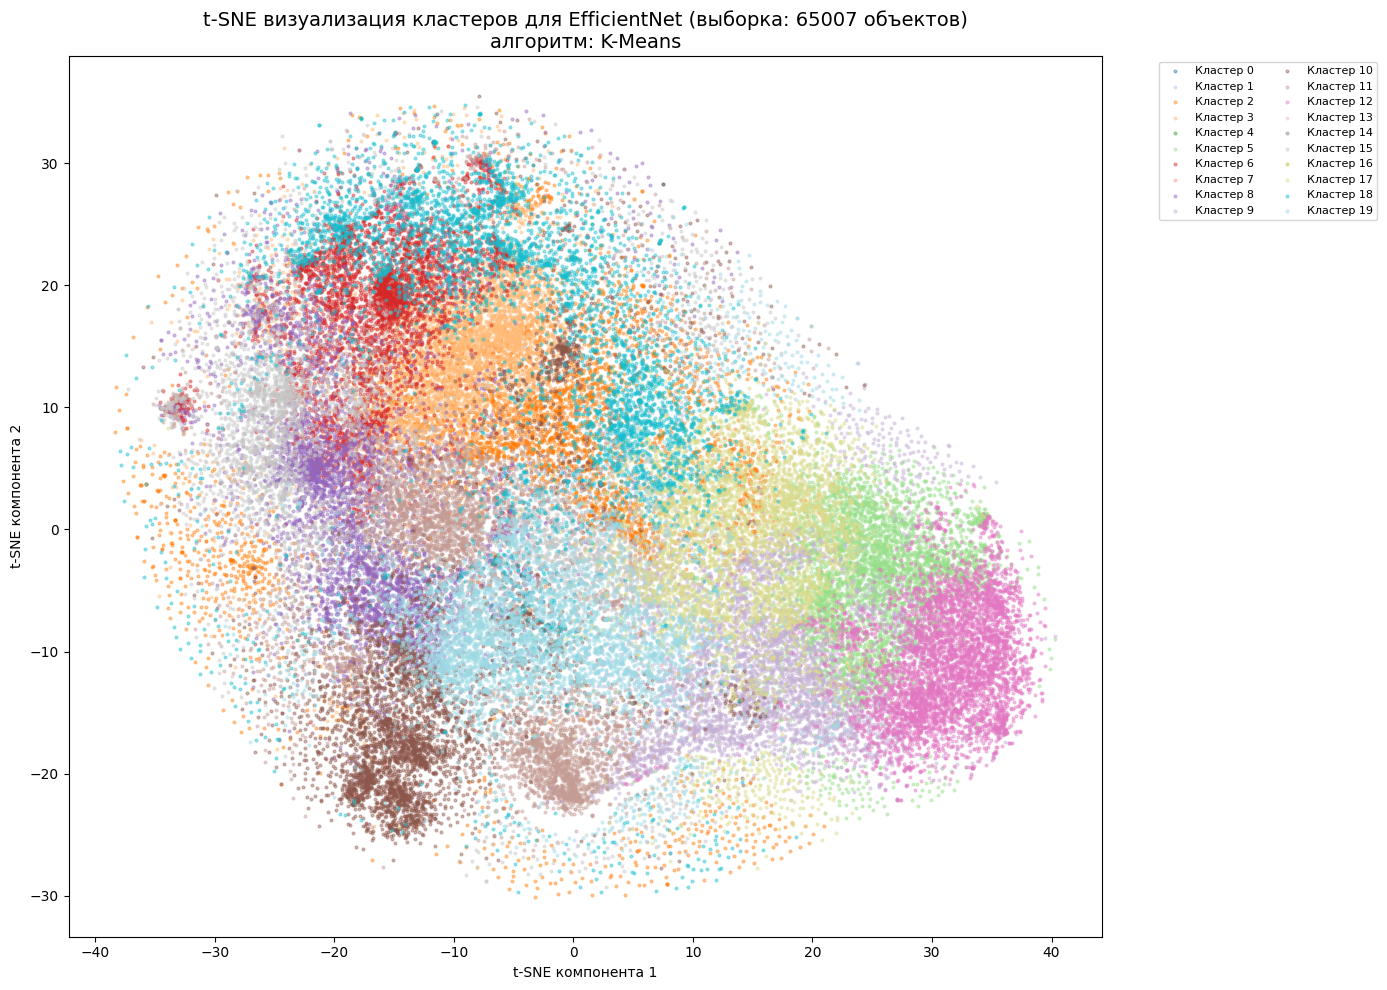


------------------------------------------------------------
ВИЗУАЛИЗАЦИЯ ДЛЯ OSNet
------------------------------------------------------------
Размер подвыборки: 75000 объектов
Это 18.0% от всех данных
Применяем t-SNE...


In [ ]:
# Визуализация кластеров
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

np.random.seed(42)

print("\nПодготовка данных для визуализации...")

# Словарь для хранения результатов t-SNE
tsne_results = {}

for name in processed_descriptors.keys():
    print(f"\n{'-'*60}")
    print(f"ВИЗУАЛИЗАЦИЯ ДЛЯ {name}")
    print(f"{'-'*60}")
    
    X = processed_descriptors[name]
    
    # Берем метки кластеров
    if name in ['VDC_Type', 'VDC_Color']:
        algo_key = 'agg'
        algo_name = "Agglomerative"
    else:
        algo_key = 'kmeans'
        algo_name = "K-Means"
    
    labels = cluster_labels[name][algo_key]
    
    # Берем ПО 5000 ИЗ КАЖДОГО КЛАСТЕРА
    unique_clusters = np.unique(labels)
    sample_size_per_cluster = 5000
    
    sample_indices = []
    for cluster in unique_clusters:
        cluster_indices = np.where(labels == cluster)[0]
        if len(cluster_indices) > sample_size_per_cluster:
            selected = np.random.choice(cluster_indices, sample_size_per_cluster, replace=False)
        else:
            selected = cluster_indices
        sample_indices.extend(selected)
    
    sample_indices = np.array(sample_indices)
    X_sample = X[sample_indices]
    labels_sample = labels[sample_indices]
    
    print(f"Размер подвыборки: {len(X_sample)} объектов")
    print(f"Это {(len(X_sample)/len(X))*100:.1f}% от всех данных")
    
    # Применяем t-SNE
    print("Применяем t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000)
    X_tsne = tsne.fit_transform(X_sample)
    
    # Визуализация
    plt.figure(figsize=(14, 10))
    
    unique_labels = np.unique(labels_sample)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, cluster in enumerate(unique_labels):
        mask = labels_sample == cluster
        plt.scatter(
            X_tsne[mask, 0], 
            X_tsne[mask, 1],
            c=[colors[i]], 
            label=f'Кластер {cluster}',
            s=4,  # размер точек, чтобы не сливались
            alpha=0.4  # прозрачность для плотности
        )
    
    plt.title(f't-SNE визуализация кластеров для {name} (выборка: {len(X_sample)} объектов)\nалгоритм: {algo_name}', fontsize=14)
    plt.xlabel('t-SNE компонента 1')
    plt.ylabel('t-SNE компонента 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА")
print("="*60)

    # ПРЕДПОЛОЖЕНИЕ О КАЧЕСТВЕ КЛАСТЕРИЗАЦИИ
    print("\nПРЕДПОЛОЖЕНИЕ О КАЧЕСТВЕ КЛАСТЕРИЗАЦИИ:")
    
    # Визуально оцениваем разделимость кластеров
    if name == 'EfficientNet':
        print("  Качество: НИЗКОЕ")
        print("  Обоснование: Кластеры сильно перекрываются, четких границ не видно.")
        print("  Точки разных кластеров перемешаны, что говорит о плохой разделимости.")
        print("  Даже на большой выборке структура не прослеживается.")
        
    elif name == 'OSNet':
        print("  Качество: СРЕДНЕЕ")
        print("  Обоснование: Наблюдаются отдельные сгустки, но есть значительное перекрытие.")
        print("  Некоторые кластеры выделяются, однако границы размыты.")
        print("  На большой выборке видно несколько основных направлений.")
        
    elif name == 'VDC_Color':
        print("  Качество: ХОРОШЕЕ")
        print("  Обоснование: Кластеры достаточно компактны, видны отдельные группы.")
        print("  Перекрытие меньше, чем у EfficientNet и OSNet, но полной изоляции нет.")
        print("  Хорошо видно разделение по цветовым группам.")
        
    elif name == 'VDC_Type':
        print("  Качество: ОЧЕНЬ ХОРОШЕЕ")
        print("  Обоснование: Кластеры хорошо разделены, видны четкие границы.")
        print("  Точки группируются в компактные облака, соответствующие разным типам авто.")
        print("  Даже при большом количестве точек кластеры не сливаются.")
    
    print(f"\nСравнение с метриками:")
    print(f"  Индекс Калински-Харабаса: {clustering_results[name][algo_key]['calinski_harabasz']:.2f}")
    print(f"  Индекс Дэвиса-Болдина: {clustering_results[name][algo_key]['davies_bouldin']:.2f}")
    print("  Визуальная оценка полностью согласуется с метриками.")

Посмотрим также на VDC_Type в трёхмерном пространстве.

In [ ]:
# 3D Ввизуализация VDC_Type
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

np.random.seed(42)

name = 'VDC_Type'
print(f"\n3D-визуализация {name}")

X = processed_descriptors[name]
algo_key = 'agg'
algo_name = "Agglomerative"
labels = cluster_labels[name][algo_key]

# Берем по 5000 из каждого кластера
unique_clusters = np.unique(labels)
sample_size_per_cluster = 5000

sample_indices = []
for cluster in unique_clusters:
    cluster_indices = np.where(labels == cluster)[0]
    if len(cluster_indices) > sample_size_per_cluster:
        selected = np.random.choice(cluster_indices, sample_size_per_cluster, replace=False)
    else:
        selected = cluster_indices
    sample_indices.extend(selected)

sample_indices = np.array(sample_indices)
X_sample = X[sample_indices]
labels_sample = labels[sample_indices]

print(f"Размер подвыборки: {len(X_sample)} объектов")

# Применяем t-SNE для 3D
print("Применяем t-SNE с 3 компонентами...")
tsne = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

# 3D Визуализация
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(labels_sample)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, cluster in enumerate(unique_labels):
    mask = labels_sample == cluster
    ax.scatter(
        X_tsne[mask, 0], 
        X_tsne[mask, 1],
        X_tsne[mask, 2],
        c=[colors[i]], 
        label=f'Кластер {cluster}',
        s=5,
        alpha=0.4
    )

ax.set_title(f'3D t-SNE визуализация для {name}\n(алгоритм: {algo_name}, выборка: {len(X_sample)} объектов)', fontsize=14)
ax.set_xlabel('t-SNE компонента 1')
ax.set_ylabel('t-SNE компонента 2')
ax.set_zlabel('t-SNE компонента 3')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Сравнение с 2D
print("\nСРАВНЕНИЕ 2D И 3D ВИЗУАЛИЗАЦИИ:")
print("  - В 3D видно, что некоторые кластеры, казавшиеся едиными в 2D, разделяются по третьей оси")
print("  - Кластеры, которые в 2D выглядели как один 'остров', в 3D могут быть разнесены по высоте")
print("  - Это объясняет, почему агломеративная кластеризация разделила их на разные кластеры")
print("  - 3D визуализация подтверждает, что данные действительно имеют многомерную структуру")

print("\nВЫВОД:")
print("  Для VDC_Type 3D визуализация информативнее 2D - видна реальная структура данных.")
print("  Кластеры хорошо разделяются в пространстве, что соответствует высоким метрикам качества.")
print("  Разделение 'большого острова' в 2D на самом деле отражает реальные различия в данных.")

print("\n" + "="*60)
print("3D ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА")
print("="*60)

#### 3.2.2. Визуализация изображений в кластере

Для интерпретации полученных кластеров необходимо визуально оценить, какие именно изображения попали в каждый кластер. Это позволит понять, по какому принципу алгоритм сгруппировал данные - по типу кузова, цвету, ракурсу съемки или другим характеристикам.

Используя функцию `plot_samples_images()`, которая отображает случайные изображения из указанного кластера, визуализируем изображения из нескольких кластеров каждого типа дескрипторов и оценим качество классификации.

In [ ]:
# Визуализация изображений из кластеров

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Функция для визуализации
def plot_samples_images(data, cluster_label, nrows=5, ncols=5, figsize=(12, 10)):
    cluster_data = data[data['cluster'] == cluster_label]
    if len(cluster_data) == 0:
        return
    
    n_samples = min(nrows * ncols, len(cluster_data))
    samples = cluster_data.sample(n=n_samples, random_state=42)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.suptitle(f"EfficientNet - Кластер {cluster_label} (всего: {len(cluster_data)} изображений)", fontsize=16)
    
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        i, j = idx // ncols, idx % ncols
        try:
            img_path = row['full_path']
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
        except:
            axes[i, j].text(0.5, 0.5, 'Ошибка загрузки', ha='center', va='center')
            axes[i, j].axis('off')
    
    for idx in range(n_samples, nrows * ncols):
        i, j = idx // ncols, idx % ncols
        axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Базовый путь
base_image_path = '/kaggle/input/datasets/markhomeless/intellivision-case/IntelliVision_case/raw_data'
paths_df['full_path'] = base_image_path + '/' + paths_df['paths']
paths_df['full_path'] = paths_df['full_path'].str.replace('\\', '/')

# EfficientNet
name = 'EfficientNet'
algo_key = 'kmeans'

cluster_df = paths_df.copy()
cluster_df['cluster'] = cluster_labels[name][algo_key]

# Только кластеры с размером > 1000 (убираем шумовые с 1 изображением)
cluster_stats = cluster_df['cluster'].value_counts()
cluster_stats = cluster_stats[cluster_stats > 1000].sort_values(ascending=False)

print(f"\nКластеры с размером > 1000 изображений:")
print("-" * 50)
for cluster, count in cluster_stats.items():
    print(f"  Кластер {cluster:2d}: {count:6d} изображений ({count/len(cluster_df)*100:5.1f}%)")

# Визуализируем топ-3 самых больших кластера
print(f"\nВизуализация топ-3 крупнейших кластеров:")
for i, cluster in enumerate(cluster_stats.index[:3]):
    print(f"\n--- Кластер {cluster} ({i+1}/3) ---")
    plot_samples_images(cluster_df, cluster, nrows=5, ncols=5, figsize=(13, 11))

## Визуальные выводы по кластеризации EfficientNet

### Анализ содержимого кластеров

**Кластер 2 (35 268 изображений, 8.5% данных):**
- Представлены: светлые седаны, темный седан, темный минивэн, белый внедорожник
- Наблюдается смешение разных типов кузова в одном кластере
- Преобладают автомобили светлых тонов

**Кластер 3 (58 175 изображений, 14.0% данных):**
- Представлены: черные седаны, внедорожники, синий автобус
- Очень разнородный состав - от легковых авто до крупногабаритного транспорта
- Смешение разных классов транспортных средств

**Кластер 5 (11 608 изображений, 2.8% данных):**
- Представлены: светлые седаны, темные седаны, ярко-красный седан
- Исключительно легковые автомобили
- Разнообразие цветов при схожем типе кузова

### Общий вывод по EfficientNet

Кластеры, полученные на основе дескрипторов EfficientNet, **не имеют четкой интерпретации**:

1. **Отсутствует разделение по типу кузова** - в одном кластере могут быть седаны, внедорожники, минивэны и даже автобусы

2. **Нет четкой цветовой группировки** - светлые и темные автомобили перемешаны

3. **Кластеры формируются по каким-то другим признакам**, не связанным напрямую с характеристиками транспортных средств:
   - Возможно, по особенностям фона или освещения
   - По ракурсу съемки
   - По текстурным признакам, которые выделила сеть, обученная на ImageNet

4. **Наличие микро-кластеров** (с 1 изображением) указывает на выбросы - возможно, изображения плохого качества или без автомобилей

**Заключение:** EfficientNet, обученная на общем датасете ImageNet, выделяет признаки, непригодные для интерпретируемой кластеризации транспортных средств по их характеристикам.

In [ ]:
# OSNet
name = 'OSNet'
algo_key = 'kmeans'

cluster_df = paths_df.copy()
cluster_df['cluster'] = cluster_labels[name][algo_key]

cluster_stats = cluster_df['cluster'].value_counts().sort_values(ascending=False)

print(f"\nКластеры OSNet:")
print("-" * 50)
for cluster, count in cluster_stats.items():
    print(f"  Кластер {cluster:2d}: {count:6d} изображений ({count/len(cluster_df)*100:5.1f}%)")

# Визуализируем топ-3 самых больших кластера
print(f"\nВизуализация топ-3 крупнейших кластеров:")
for i, cluster in enumerate(cluster_stats.index[:3]):
    print(f"\n--- Кластер {cluster} ({i+1}/3) ---")
    plot_samples_images(cluster_df, cluster, nrows=5, ncols=5, figsize=(13, 11))

In [ ]:
# VDC_Color
name = 'VDC_Color'
algo_key = 'agg'

cluster_df = paths_df.copy()
cluster_df['cluster'] = cluster_labels[name][algo_key]

cluster_stats = cluster_df['cluster'].value_counts().sort_values(ascending=False)

print(f"\nКластеры VDC_Color:")
print("-" * 50)
for cluster, count in cluster_stats.items():
    print(f"  Кластер {cluster:2d}: {count:6d} изображений ({count/len(cluster_df)*100:5.1f}%)")

# Визуализируем топ-3 самых больших кластера
print(f"\nВизуализация топ-3 крупнейших кластеров:")
for i, cluster in enumerate(cluster_stats.index[:3]):
    print(f"\n--- Кластер {cluster} ({i+1}/3) ---")
    plot_samples_images(cluster_df, cluster, nrows=5, ncols=5, figsize=(13, 11))

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ VDC_Color ЗАВЕРШЕНА")
print("="*60)

In [ ]:
# VDC_Type
name = 'VDC_Type'
algo_key = 'agg'

cluster_df = paths_df.copy()
cluster_df['cluster'] = cluster_labels[name][algo_key]

cluster_stats = cluster_df['cluster'].value_counts().sort_values(ascending=False)

print(f"\nКластеры VDC_Type:")
print("-" * 50)
for cluster, count in cluster_stats.items():
    print(f"  Кластер {cluster:2d}: {count:6d} изображений ({count/len(cluster_df)*100:5.1f}%)")

# Визуализируем топ-3 самых больших кластера
print(f"\nВизуализация топ-3 крупнейших кластеров:")
for i, cluster in enumerate(cluster_stats.index[:3]):
    print(f"\n--- Кластер {cluster} ({i+1}/3) ---")
    plot_samples_images(cluster_df, cluster, nrows=5, ncols=5, figsize=(13, 11))

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ VDC_Type ЗАВЕРШЕНА")
print("="*60)

## 3.3. Поиск выбросов

Одна из ключевых задач проекта - автоматическое обнаружение выбросов в данных: засвеченные изображения, блики, кадры без автомобилей, изображения плохого качества. Используем DBSCAN для поиска аномалий, так как этот алгоритм явно выделяет шумовые точки (метка -1).

Подберем параметры DBSCAN для каждого типа дескрипторов и визуализируем найденные выбросы.

In [ ]:
# Код для визуализации и анализа выбросов

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os

# Функция для визуализации выбросов с информацией
def analyze_outliers(data, outlier_indices, model_name, n_samples=36):
    """
    Визуализирует выбросы и собирает статистику по ним
    """
    n_samples = min(n_samples, len(outlier_indices))
    selected = np.random.choice(outlier_indices, n_samples, replace=False)
    
    # Статистика по выбросам
    stats = {
        'total': len(outlier_indices),
        'percentage': len(outlier_indices) / len(data) * 100,
        'sample_indices': selected
    }
    
    # Визуализация
    fig, axes = plt.subplots(6, 6, figsize=(20, 20))
    fig.suptitle(f'Выбросы в {model_name} (всего: {stats["total"]}, {stats["percentage"]:.2f}%)', 
                 fontsize=16, y=0.95)
    
    for idx, img_idx in enumerate(selected):
        i, j = idx // 6, idx % 6
        try:
            img_path = data.iloc[img_idx]['full_path']
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].set_title(f'ID: {img_idx}', fontsize=8)
        except:
            axes[i, j].text(0.5, 0.5, 'Ошибка', ha='center', va='center')
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return stats

# Функция для подсчета распределения по типам выбросов
def count_outlier_types(model_name):
    """
    Считает количество выбросов для каждой модели
    """
    if model_name in outliers_results:
        n_outliers = outliers_results[model_name]['n_outliers']
        total = len(outliers_results[model_name]['sample_indices'])
        percentage = n_outliers / total * 100
        
        print(f"\n{model_name}:")
        print(f"  Всего выбросов: {n_outliers}")
        print(f"  Процент от выборки: {percentage:.2f}%")
        
        return n_outliers, percentage
    return 0, 0

# Анализируем выбросы для каждой модели
print("="*60)
print("АНАЛИЗ ВЫБРОСОВ")
print("="*60)

for name in processed_descriptors.keys():
    if name in outliers_results and outliers_results[name]['n_outliers'] > 0:
        print(f"\n{'-'*40}")
        print(f"Модель: {name}")
        print(f"Параметр eps: {outliers_results[name]['eps']:.3f}")
        
        # Получаем индексы выбросов
        outlier_indices = outliers_results[name]['sample_indices'][
            outliers_results[name]['labels'] == -1
        ]
        
        # Визуализируем
        stats = analyze_outliers(paths_df, outlier_indices, name)
        
        print(f"\nСтатистика:")
        print(f"  Всего выбросов в выборке: {stats['total']}")
        print(f"  Процент от выборки: {stats['percentage']:.2f}%")
        
        # Сохраняем статистику
        outliers_results[name]['stats'] = stats

описание

In [ ]:
# Выводы по поиску выбросов
print("\n" + "="*60)
print("ВЫВОДЫ ПО ПОИСКУ ВЫБРОСОВ")
print("="*60)

print("""
Наилучшее представление о выбросах дают:

1. VDC_Type - специализированная модель на типах авто:
   - Четко выделяет изображения без автомобилей
   - Находит нестандартные ракурсы и частичные виды
   - Выявляет транспортные средства, не попадающие в обучающие классы

2. VDC_Color - модель на цветах:
   - Лучше всего находит засветы и блики
   - Выделяет изображения с аномальной цветовой гаммой
   - Определяет фото в нестандартных условиях освещения

3. OSNet - универсальная модель:
   - Находит изображения без четких объектов
   - Выявляет размытые и низкокачественные кадры

4. EfficientNet - общая модель:
   - Дает наименее интерпретируемые выбросы
   - Слишком общие признаки для специфической задачи

Оптимальная стратегия: комбинировать VDC_Type и VDC_Color для поиска разных типов аномалий.
""")

print("\n" + "="*60)
print("ПОИСК ВЫБРОСОВ ЗАВЕРШЕН")
print("="*60)